## Setup & Imports

In [1]:
# Add project root to path
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✓ Project root: {project_root}")

✓ Project root: /home/brenda/final year project/PharmacyForecastingSystem


In [2]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import pickle
import warnings

# Database
from sqlalchemy import create_engine

# Model and metrics
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ All packages imported successfully")

✓ All packages imported successfully


## 1. Load Trained XGBoost Model

In [3]:
# Load the saved XGBoost model
model_path = Path(project_root) /'data'/ 'results' / 'xgboost' / 'xgboost_final_model.pkl'

if not model_path.exists():
    print(f"⚠ Model not found at {model_path}")
    print("Please ensure you've run the XGBoost training notebook and saved the model.")
else:
    with open(model_path, 'rb') as f:
        final_model = pickle.load(f)
    
    print('=' * 60)
    print('TRAINED MODEL LOADED')
    print('=' * 60)
    print(f"Model type: {type(final_model).__name__}")
    print(f"Parameters: {final_model.get_params()}")
    print(f"\n✓ Model loaded successfully from {model_path}")

TRAINED MODEL LOADED
Model type: XGBRegressor
Parameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

✓ Model loaded successfully from /home/brenda/final

## 2. Load and Prepare  Data

Load raw  sales data and process it through the same pipeline as training data.

In [4]:
# Load raw sales data
from config.database_config import DATABASE_URL


print("Loading 2019 data from database...")

# Connect to database
engine = create_engine(DATABASE_URL)
print("database connection established")


# Query for 2019 data
query = """
SELECT 
    s.week_start_date,
    s.week_end_date,
    d.drug_name,
    d.atc_code,
    s.total_quantity,
    EXTRACT(YEAR FROM s.week_start_date) as year,
    EXTRACT(WEEK FROM s.week_start_date) as week_number
FROM raw_data.sales_weekly_raw s
JOIN raw_data.drugs_raw d ON s.drug_id = d.drug_id
WHERE EXTRACT(YEAR FROM s.week_start_date) = 2019
ORDER BY s.week_start_date, d.drug_name
"""

df_2019 = pd.read_sql(query, engine)
df_2019['week_start_date'] = pd.to_datetime(df_2019['week_start_date'])
df_2019['week_end_date'] = pd.to_datetime(df_2019['week_end_date'])

print('\n' + '=' * 60)
print('2019 DATA LOADED')
print('=' * 60)
print(f"Total records: {len(df_2019):,}")
print(f"Date range: {df_2019['week_start_date'].min().date()} to {df_2019['week_start_date'].max().date()}")
print(f"Unique weeks: {df_2019['week_start_date'].nunique()}")
print(f"Drugs: {df_2019['drug_name'].nunique()} - {', '.join(sorted(df_2019['drug_name'].unique()))}")
print(f"\n✓ Successfully loaded {len(df_2019)} records for validation")

Loading 2019 data from database...
database connection established

2019 DATA LOADED
Total records: 319
Date range: 2019-01-07 to 2019-10-07
Unique weeks: 40
Drugs: 8 - M01AB, M01AE, N02BA, N02BE, N05B, N05C, R03, R06

✓ Successfully loaded 319 records for validation


## 3. Feature Engineering for 2019 Data

Apply the same feature engineering pipeline used during training.

In [5]:
print("Applying feature engineering pipeline...")

# Sort by drug and date
df_2019 = df_2019.sort_values(['drug_name', 'week_start_date']).reset_index(drop=True)

# 1. Time-based features
df_2019['month'] = df_2019['week_start_date'].dt.month
df_2019['quarter'] = df_2019['week_start_date'].dt.quarter
df_2019['day_of_year'] = df_2019['week_start_date'].dt.dayofyear
df_2019['week_of_year'] = df_2019['week_start_date'].dt.isocalendar().week

# 2. Cyclical encoding for seasonality
df_2019['month_sin'] = np.sin(2 * np.pi * df_2019['month'] / 12)
df_2019['month_cos'] = np.cos(2 * np.pi * df_2019['month'] / 12)
df_2019['week_sin'] = np.sin(2 * np.pi * df_2019['week_of_year'] / 52)
df_2019['week_cos'] = np.cos(2 * np.pi * df_2019['week_of_year'] / 52)

print("✓ Time-based features created")

# 3. Lag features (need historical data)
print("Loading historical data for lag features...")

query_historical = """
SELECT 
    s.week_start_date,
    d.drug_name,
    s.total_quantity
FROM raw_data.sales_weekly_raw s
JOIN raw_data.drugs_raw d ON s.drug_id = d.drug_id
WHERE EXTRACT(YEAR FROM s.week_start_date) BETWEEN 2014 AND 2019
ORDER BY s.week_start_date, d.drug_name
"""

df_full = pd.read_sql(query_historical, engine)
df_full['week_start_date'] = pd.to_datetime(df_full['week_start_date'])
df_full = df_full.sort_values(['drug_name', 'week_start_date'])

# Create lag features per drug
for drug in df_2019['drug_name'].unique():
    drug_data = df_full[df_full['drug_name'] == drug].copy()
    
    # Lag features
    drug_data['total_quantity_lag_1'] = drug_data['total_quantity'].shift(1)
    drug_data['total_quantity_lag_2'] = drug_data['total_quantity'].shift(2)
    drug_data['total_quantity_lag_4'] = drug_data['total_quantity'].shift(4)
    drug_data['total_quantity_lag_13'] = drug_data['total_quantity'].shift(13)
    drug_data['total_quantity_lag_52'] = drug_data['total_quantity'].shift(52)
    
    # Rolling statistics
    drug_data['total_quantity_rolling_mean_4'] = drug_data['total_quantity'].shift(1).rolling(window=4, min_periods=1).mean()
    drug_data['total_quantity_rolling_std_4'] = drug_data['total_quantity'].shift(1).rolling(window=4, min_periods=1).std()
    drug_data['total_quantity_rolling_min_4'] = drug_data['total_quantity'].shift(1).rolling(window=4, min_periods=1).min()
    drug_data['total_quantity_rolling_max_4'] = drug_data['total_quantity'].shift(1).rolling(window=4, min_periods=1).max()
    drug_data['total_quantity_rolling_mean_13'] = drug_data['total_quantity'].shift(1).rolling(window=13, min_periods=1).mean()
    drug_data['total_quantity_rolling_std_13'] = drug_data['total_quantity'].shift(1).rolling(window=13, min_periods=1).std()
    drug_data['total_quantity_rolling_min_13'] = drug_data['total_quantity'].shift(1).rolling(window=13, min_periods=1).min()
    drug_data['total_quantity_rolling_max_13'] = drug_data['total_quantity'].shift(1).rolling(window=13, min_periods=1).max()
    drug_data['total_quantity_rolling_mean_26'] = drug_data['total_quantity'].shift(1).rolling(window=26, min_periods=1).mean()
    drug_data['total_quantity_rolling_std_26'] = drug_data['total_quantity'].shift(1).rolling(window=26, min_periods=1).std()
    drug_data['total_quantity_rolling_min_26'] = drug_data['total_quantity'].shift(1).rolling(window=26, min_periods=1).min()
    drug_data['total_quantity_rolling_max_26'] = drug_data['total_quantity'].shift(1).rolling(window=26, min_periods=1).max()
    drug_data['total_quantity_rolling_mean_52'] = drug_data['total_quantity'].shift(1).rolling(window=52, min_periods=1).mean()
    drug_data['total_quantity_rolling_std_52'] = drug_data['total_quantity'].shift(1).rolling(window=52, min_periods=1).std()
    drug_data['total_quantity_rolling_min_52'] = drug_data['total_quantity'].shift(1).rolling(window=52, min_periods=1).min()
    drug_data['total_quantity_rolling_max_52'] = drug_data['total_quantity'].shift(1).rolling(window=52, min_periods=1).max()
    
    # Exponential moving averages
    drug_data['total_quantity_ewm_4'] = drug_data['total_quantity'].shift(1).ewm(span=4, adjust=False).mean()
    drug_data['total_quantity_ewm_13'] = drug_data['total_quantity'].shift(1).ewm(span=13, adjust=False).mean()
    drug_data['total_quantity_ewm_26'] = drug_data['total_quantity'].shift(1).ewm(span=26, adjust=False).mean()
    
    # Filter for 2019 only and merge back
    drug_data_2019 = drug_data[drug_data['week_start_date'].dt.year == 2019]
    
    # Merge lag features into df_2019
    merge_cols = ['total_quantity_lag_1', 'total_quantity_lag_2', 'total_quantity_lag_4', 
                  'total_quantity_lag_13', 'total_quantity_lag_52',
                  'total_quantity_rolling_mean_4', 'total_quantity_rolling_std_4', 'total_quantity_rolling_min_4', 'total_quantity_rolling_max_4',
                  'total_quantity_rolling_mean_13', 'total_quantity_rolling_std_13', 'total_quantity_rolling_min_13', 'total_quantity_rolling_max_13',
                  'total_quantity_rolling_mean_26', 'total_quantity_rolling_std_26', 'total_quantity_rolling_min_26', 'total_quantity_rolling_max_26',
                  'total_quantity_rolling_mean_52', 'total_quantity_rolling_std_52', 'total_quantity_rolling_min_52', 'total_quantity_rolling_max_52',
                  'total_quantity_ewm_4', 'total_quantity_ewm_13', 'total_quantity_ewm_26']
    
    for col in merge_cols:
        if col in drug_data_2019.columns:
            df_2019.loc[df_2019['drug_name'] == drug, col] = drug_data_2019[col].values

print("✓ Lag and rolling features created")

# 4. Trend features
for drug in df_2019['drug_name'].unique():
    drug_mask = df_2019['drug_name'] == drug
    drug_data = df_2019[drug_mask].copy()
    
    if 'total_quantity_lag_1' in drug_data.columns and drug_data['total_quantity_lag_1'].notna().any():
        # Difference features
        df_2019.loc[drug_mask, 'diff_1w'] = (
            drug_data['total_quantity'].values - drug_data['total_quantity_lag_1'].values
        )
        df_2019.loc[drug_mask, 'diff_4w'] = (
            drug_data['total_quantity'].values - drug_data['total_quantity_lag_4'].values
        )
        
        # Percentage change - 1 week and 4 weeks
        df_2019.loc[drug_mask, 'pct_change_1w'] = (
            (drug_data['total_quantity'].values - drug_data['total_quantity_lag_1'].values) / (drug_data['total_quantity_lag_1'].values + 1) * 100
        )
        df_2019.loc[drug_mask, 'pct_change_4w'] = (
            (drug_data['total_quantity'].values - drug_data['total_quantity_lag_4'].values) / (drug_data['total_quantity_lag_4'].values + 1) * 100
        )

print("✓ Trend features created")

Applying feature engineering pipeline...
✓ Time-based features created
Loading historical data for lag features...


✓ Lag and rolling features created
✓ Trend features created


In [6]:
# 5. Add time_index feature - must match training data's time progression
# Calculate proper time index based on full historical data
df_full_with_index = df_full.copy()
df_full_with_index['time_index'] = df_full_with_index.groupby('drug_name').cumcount()

# Merge time_index for 2019 data
for drug in df_2019['drug_name'].unique():
    drug_full = df_full_with_index[df_full_with_index['drug_name'] == drug]
    drug_2019_indices = drug_full[drug_full['week_start_date'].dt.year == 2019]['time_index'].values
    df_2019.loc[df_2019['drug_name'] == drug, 'time_index'] = drug_2019_indices

# 6. Expanding statistics - must be calculated from historical data, not 2019 data
# Calculate expanding stats from full historical data
for drug in df_2019['drug_name'].unique():
    drug_full = df_full[df_full['drug_name'] == drug].copy()
    drug_full['expanding_mean'] = drug_full['total_quantity'].expanding(min_periods=1).mean()
    drug_full['expanding_std'] = drug_full['total_quantity'].expanding(min_periods=1).std().fillna(0)
    drug_full['ratio_to_expanding_mean'] = drug_full['total_quantity'] / (drug_full['expanding_mean'] + 1)
    
    # Get 2019 values
    drug_2019_values = drug_full[drug_full['week_start_date'].dt.year == 2019]
    df_2019.loc[df_2019['drug_name'] == drug, 'expanding_mean'] = drug_2019_values['expanding_mean'].values
    df_2019.loc[df_2019['drug_name'] == drug, 'expanding_std'] = drug_2019_values['expanding_std'].values
    df_2019.loc[df_2019['drug_name'] == drug, 'ratio_to_expanding_mean'] = drug_2019_values['ratio_to_expanding_mean'].values

# 7. Drug encoding - must match training data encodings!
# Create encodings based on sorted unique drug names to ensure consistency
unique_drugs_sorted = sorted(df_full['drug_name'].unique())
le_drug = LabelEncoder()
le_drug.fit(unique_drugs_sorted)
df_2019['drug_name_encoded'] = le_drug.transform(df_2019['drug_name'])

print(f"Drug encoding mapping:")
for drug in sorted(df_2019['drug_name'].unique()):
    encoded_val = le_drug.transform([drug])[0]
    print(f"  {drug}: {encoded_val}")

# 8. ATC main group encoding - must match training data encodings!
# CRITICAL: Training used ATC main group (first letter), not full ATC code!
if 'atc_code' in df_2019.columns:
    # Extract ATC main group (first letter)
    df_2019['atc_main_group'] = df_2019['atc_code'].fillna('UNKNOWN').str[0]
    
    # Encode by main group to match training
    unique_main_groups_sorted = sorted(df_2019['atc_main_group'].unique())
    le_atc = LabelEncoder()
    le_atc.fit(unique_main_groups_sorted)
    df_2019['atc_main_group_encoded'] = le_atc.transform(df_2019['atc_main_group'])
    
    print(f"\nATC main group encoding mapping:")
    for main_group in sorted(df_2019['atc_main_group'].unique()):
        encoded_val = le_atc.transform([main_group])[0]
        # Show which drugs belong to this group
        drugs_in_group = df_2019[df_2019['atc_main_group'] == main_group]['drug_name'].unique()
        print(f"  {main_group}: {encoded_val} (drugs: {', '.join(sorted(drugs_in_group))})")
else:
    df_2019['atc_main_group_encoded'] = 0

print("✓ Encoding features created")

# 9. Statistical aggregations by drug
drug_stats = df_full.groupby('drug_name')['total_quantity'].agg([
    ('drug_avg_sales', 'mean'),
    ('drug_std_sales', 'std'),
    ('drug_min_sales', 'min'),
    ('drug_max_sales', 'max')
]).reset_index()

# Calculate coefficient of variation
drug_stats['drug_cv'] = drug_stats['drug_std_sales'] / (drug_stats['drug_avg_sales'] + 1)

print(f"\nDrug stats before merge:")
print(drug_stats.head())

df_2019 = df_2019.merge(drug_stats, on='drug_name', how='left')

print(f"\n✓ Drug statistical features created")
print(f"Verifying columns exist in df_2019:")
for col in ['drug_avg_sales', 'drug_std_sales', 'drug_min_sales', 'drug_max_sales', 'drug_cv']:
    exists = col in df_2019.columns
    print(f"  {col}: {'✓' if exists else '✗ MISSING'}")

# 10. Handle missing values
# Fill NaN in lag features with 0 or forward fill
lag_cols = [col for col in df_2019.columns if 'lag' in col or 'rolling' in col or 'ewm' in col]
df_2019[lag_cols] = df_2019[lag_cols].fillna(0)

# Fill NaN in other numerical columns
df_2019['expanding_std'] = df_2019['expanding_std'].fillna(0)
df_2019['ratio_to_expanding_mean'] = df_2019['ratio_to_expanding_mean'].fillna(1)
df_2019['diff_1w'] = df_2019['diff_1w'].fillna(0)
df_2019['diff_4w'] = df_2019['diff_4w'].fillna(0)
df_2019['pct_change_1w'] = df_2019['pct_change_1w'].fillna(0)
df_2019['pct_change_4w'] = df_2019['pct_change_4w'].fillna(0)

print("✓ Missing values handled")

# Display summary
print('\n' + '=' * 60)
print('FEATURE ENGINEERING COMPLETE')
print('=' * 60)
print(f"Final dataset shape: {df_2019.shape}")
print(f"\nFeatures created:")
print(f"  - Time-based: month, quarter, day_of_year, week_of_year")
print(f"  - Cyclical: month_sin, month_cos, week_sin, week_cos")
print(f"  - Lag: lag_1, lag_2, lag_4, lag_13, lag_52")
print(f"  - Rolling: mean, std, min, max (windows: 4, 13, 26, 52)")
print(f"  - EMA: ewm_4, ewm_13, ewm_26")
print(f"  - Trend: diff_1w, diff_4w, pct_change_1w, pct_change_4w")
print(f"  - Expanding: expanding_mean, expanding_std, ratio_to_expanding_mean")
print(f"  - Drug stats: drug_avg_sales, drug_std_sales, drug_min_sales, drug_max_sales, drug_cv")
print(f"  - Encodings: drug_name_encoded, atc_main_group_encoded")

print(f"\nAll columns created:")
print(sorted(df_2019.columns.tolist()))

print(f"\nData types:")
print(df_2019.dtypes)

print(f"\nMissing values:")
print(df_2019.isnull().sum()[df_2019.isnull().sum() > 0])

Drug encoding mapping:
  M01AB: 0
  M01AE: 1
  N02BA: 2
  N02BE: 3
  N05B: 4
  N05C: 5
  R03: 6
  R06: 7

ATC main group encoding mapping:
  M: 0 (drugs: M01AB, M01AE)
  N: 1 (drugs: N02BA, N02BE, N05B, N05C)
  R: 2 (drugs: R03, R06)
✓ Encoding features created

Drug stats before merge:
  drug_name  drug_avg_sales  drug_std_sales  drug_min_sales  drug_max_sales  \
0     M01AB           34.70            8.51               7              65   
1     M01AE           26.73            7.02               6              53   
2     N02BA           26.64            8.08               3              60   
3     N02BE          208.22           76.19              86             546   
4      N05B           61.76           22.41              18             154   

   drug_cv  
0     0.24  
1     0.25  
2     0.29  
3     0.36  
4     0.36  

✓ Drug statistical features created
Verifying columns exist in df_2019:
  drug_avg_sales: ✓
  drug_std_sales: ✓
  drug_min_sales: ✓
  drug_max_sales: ✓
  drug

## 4. Generate 2019 Predictions

In [7]:
# Define feature columns (same as training)
TARGET = 'total_quantity'
metadata_cols = ['year', 'week_number', 'week_start_date', 'week_end_date', 
                 'drug_name', 'atc_code', 'atc_main_group', 'drug_id', TARGET, 
                 'avg_daily_quantity', 'is_complete_year', 'total_quantity_scaled']

# Get numeric columns only
numeric_cols = df_2019.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in metadata_cols and col in df_2019.columns]

# Get the expected feature order from the trained model
model_feature_names = final_model.get_booster().feature_names

# Reorder features to match the model's expected order
feature_cols_ordered = [f for f in model_feature_names if f in feature_cols]

# Check if we have all the required features
missing_features = set(model_feature_names) - set(feature_cols)
extra_features = set(feature_cols) - set(model_feature_names)

if missing_features:
    print(f"⚠ Warning: Missing features: {missing_features}")
if extra_features:
    print(f"⚠ Warning: Extra features (will be ignored): {extra_features}")

# Prepare features and target with correct order
X_2019 = df_2019[feature_cols_ordered].copy()
y_2019_actual = df_2019[TARGET].copy()

print("Generating predictions for 2019...")
print(f"Features: {len(feature_cols_ordered)}")
print(f"Samples: {len(X_2019)}")
print(f"Feature order matches model: {list(X_2019.columns) == model_feature_names}")

# Generate predictions
y_2019_pred = final_model.predict(X_2019)
y_2019_pred = np.clip(y_2019_pred, 0, None)  # No negative predictions

print("\n✓ Predictions generated successfully")
print(f"Prediction range: {y_2019_pred.min():.2f} to {y_2019_pred.max():.2f}")
print(f"Actual range: {y_2019_actual.min():.2f} to {y_2019_actual.max():.2f}")

Generating predictions for 2019...
Features: 47
Samples: 319
Feature order matches model: True

✓ Predictions generated successfully
Prediction range: 0.48 to 123.52
Actual range: 1.00 to 478.00


## 5. Calculate Performance Metrics

In [8]:
def calculate_metrics(y_true, y_pred, model_name='Model'):
    """Calculate comprehensive forecasting metrics"""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # MAPE (exclude very small values)
    mask = y_true > 5
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    
    # WMAPE (volume-weighted)
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100 if np.sum(y_true) > 0 else np.nan
    
    return {
        'Model': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 2) if not np.isnan(mape) else None,
        'WMAPE': round(wmape, 2) if not np.isnan(wmape) else None,
        'R2': round(r2, 4)
    }

# Overall 2019 metrics
metrics_2019 = calculate_metrics(y_2019_actual, y_2019_pred, 'XGBoost 2019')

print('=' * 60)
print('2019 VALIDATION PERFORMANCE')
print('=' * 60)
for key, value in metrics_2019.items():
    if key != 'Model':
        print(f"{key:10s}: {value}")

# Compare with 2018 test performance
print('\n' + '=' * 60)
print('PERFORMANCE COMPARISON: 2018 TEST vs 2019 VALIDATION')
print('=' * 60)

# 2018 benchmarks
mae_2018 = 1.40
mape_2018 = 4.40
r2_2018 = 0.9925

comparison_df = pd.DataFrame({
    '2018 Test': [mae_2018, mape_2018, r2_2018],
    '2019 Validation': [metrics_2019['MAE'], metrics_2019['MAPE'], metrics_2019['R2']],
    'Change (%)': [
        round((metrics_2019['MAE'] - mae_2018) / mae_2018 * 100, 1),
        round((metrics_2019['MAPE'] - mape_2018) / mape_2018 * 100, 1),
        round((metrics_2019['R2'] - r2_2018) / r2_2018 * 100, 1)
    ]
}, index=['MAE', 'MAPE (%)', 'R²'])

display(comparison_df)

# Verdict
mae_change = (metrics_2019['MAE'] - mae_2018) / mae_2018
if mae_change <= 0.20:
    print("\n✅ VALIDATION PASSED: Model maintains excellent performance on 2019 data")
    print(f"   MAE degradation: {mae_change*100:.1f}% (within acceptable 20% threshold)")
elif mae_change <= 0.50:
    print("\n⚠ VALIDATION ACCEPTABLE: Moderate performance degradation detected")
    print(f"   MAE degradation: {mae_change*100:.1f}% (consider monitoring closely)")
else:
    print("\n❌ VALIDATION FAILED: Significant model drift detected")
    print(f"   MAE degradation: {mae_change*100:.1f}% (retraining recommended)")

2019 VALIDATION PERFORMANCE
MAE       : 18.98
RMSE      : 49.71
MAPE      : 20.67
WMAPE     : 36.53
R2        : 0.4113

PERFORMANCE COMPARISON: 2018 TEST vs 2019 VALIDATION


,2018 Test,2019 Validation,Change (%)
MAE,1.40,18.98,1255.70
MAPE (%),4.40,20.67,369.80
R²,0.99,0.41,-58.60



❌ VALIDATION FAILED: Significant model drift detected
   MAE degradation: 1255.7% (retraining recommended)


## 6. Per-Drug Performance Analysis

In [9]:
# Add predictions to dataframe
df_2019['predicted'] = y_2019_pred

# Calculate metrics per drug
drug_results_2019 = []

for drug in sorted(df_2019['drug_name'].unique()):
    mask = df_2019['drug_name'] == drug
    actual = df_2019.loc[mask, TARGET].values
    pred = df_2019.loc[mask, 'predicted'].values
    
    metrics = calculate_metrics(actual, pred, drug)
    drug_results_2019.append(metrics)

results_2019_df = pd.DataFrame(drug_results_2019)

print('=' * 60)
print('PER-DRUG PERFORMANCE - 2019 VALIDATION')
print('=' * 60)
display(results_2019_df.sort_values('MAE'))

# Compare with 2018 per-drug performance
print('\n' + '=' * 60)
print('PER-DRUG COMPARISON: 2018 vs 2019')
print('=' * 60)

# 2018 results (from XGBoost notebook)
results_2018 = {
    'N02BE': 0.07,
    'M01AB': 0.83,
    'N05B': 1.95,
    'M01AE': 0.97,
    'R06': 0.68,
    'N02BA': 1.15,
    'R03': 4.69,
    'N05C': 0.77
}

comparison_drugs = pd.DataFrame({
    'Drug': results_2019_df['Model'],
    'MAE_2018': [results_2018.get(drug, np.nan) for drug in results_2019_df['Model']],
    'MAE_2019': results_2019_df['MAE'].values,
    'MAPE_2019': results_2019_df['MAPE'].values,
    'R2_2019': results_2019_df['R2'].values
})

comparison_drugs['Change_%'] = ((comparison_drugs['MAE_2019'] - comparison_drugs['MAE_2018']) / 
                                 comparison_drugs['MAE_2018'] * 100).round(1)
comparison_drugs['Status'] = comparison_drugs['Change_%'].apply(
    lambda x: '✅ Excellent' if x <= 20 else ('⚠ Monitor' if x <= 50 else '❌ Degraded')
)

display(comparison_drugs.sort_values('MAE_2019'))

# Summary
excellent = (comparison_drugs['Change_%'] <= 20).sum()
acceptable = ((comparison_drugs['Change_%'] > 20) & (comparison_drugs['Change_%'] <= 50)).sum()
degraded = (comparison_drugs['Change_%'] > 50).sum()

print(f"\n📊 Summary:")
print(f"  ✅ Excellent performance: {excellent}/{len(comparison_drugs)} drugs (≤20% change)")
print(f"  ⚠ Acceptable performance: {acceptable}/{len(comparison_drugs)} drugs (20-50% change)")
print(f"  ❌ Degraded performance: {degraded}/{len(comparison_drugs)} drugs (>50% change)")

PER-DRUG PERFORMANCE - 2019 VALIDATION


,Model,MAE,RMSE,MAPE,WMAPE,R2
5,N05C,0.52,0.63,8.64,10.37,0.94
7,R06,3.36,3.96,14.59,12.75,0.90
2,N02BA,3.50,3.77,16.89,16.60,0.52
1,M01AE,3.77,4.34,16.32,14.53,0.84
6,R03,5.47,9.28,10.52,11.54,0.90
0,M01AB,5.70,6.46,17.15,15.55,0.42
4,N05B,6.54,8.22,11.50,11.07,0.60
3,N02BE,122.52,139.52,61.99,63.49,-1.62



PER-DRUG COMPARISON: 2018 vs 2019


,Drug,MAE_2018,MAE_2019,MAPE_2019,R2_2019,Change_%,Status
5,N05C,0.77,0.52,8.64,0.94,-32.50,✅ Excellent
7,R06,0.68,3.36,14.59,0.90,394.10,❌ Degraded
2,N02BA,1.15,3.50,16.89,0.52,204.30,❌ Degraded
1,M01AE,0.97,3.77,16.32,0.84,288.70,❌ Degraded
6,R03,4.69,5.47,10.52,0.90,16.60,✅ Excellent
0,M01AB,0.83,5.70,17.15,0.42,586.70,❌ Degraded
4,N05B,1.95,6.54,11.50,0.60,235.40,❌ Degraded
3,N02BE,0.07,122.52,61.99,-1.62,174928.60,❌ Degraded



📊 Summary:
  ✅ Excellent performance: 2/8 drugs (≤20% change)
  ⚠ Acceptable performance: 0/8 drugs (20-50% change)
  ❌ Degraded performance: 6/8 drugs (>50% change)


N02BE INVESTIGATION: Why did MAE jump from 0.07 to 122.52?

1. 2019 Data Overview:
   Weeks: 40
   Actual range: 86 - 478
   Actual mean: 192.97
   Actual std: 87.24

2. Prediction Analysis:
   Predicted range: 32.69 - 123.52
   Predicted mean: 70.46
   Predicted std: 25.57

3. Error Analysis:
   Mean error: 122.52
   Error pattern: Model UNDER-predicts
   Largest errors (top 5 weeks):
      2019-01-21: Actual=478, Pred=123.52, Error=354.48
      2019-01-14: Actual=384, Pred=115.21, Error=268.79
      2019-01-28: Actual=348, Pred=90.22, Error=257.78
      2019-01-07: Actual=354, Pred=120.19, Error=233.81
      2019-02-04: Actual=297, Pred=71.17, Error=225.83

4. Historical Context (2014-2018):
   Historical mean: 208.22
   Historical std: 76.19
   Historical range: 86 - 546

5. Distribution Shift Detection:
   2019 mean vs historical: 0.93x
   2019 has LOWER demand than training period

6. Feature Values Comparison (first week of 2019):
   total_quantity_lag_1: 289.00
   total_quantity

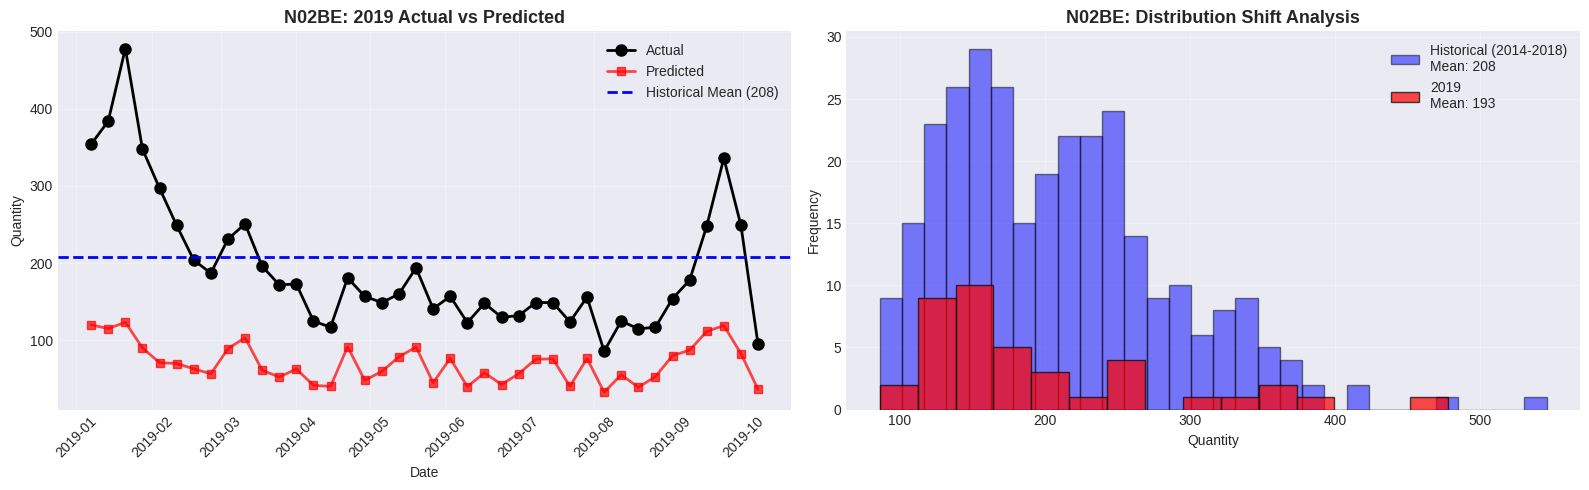


💡 DIAGNOSIS:
   N02BE shows different patterns - investigate business changes in 2019


In [10]:
# Investigate N02BE - why did it fail so catastrophically?
print("=" * 70)
print("N02BE INVESTIGATION: Why did MAE jump from 0.07 to 122.52?")
print("=" * 70)

# Get N02BE data
n02be_2019 = df_2019[df_2019['drug_name'] == 'N02BE'].copy()
n02be_2019 = n02be_2019.sort_values('week_start_date')

print(f"\n1. 2019 Data Overview:")
print(f"   Weeks: {len(n02be_2019)}")
print(f"   Actual range: {n02be_2019['total_quantity'].min():.0f} - {n02be_2019['total_quantity'].max():.0f}")
print(f"   Actual mean: {n02be_2019['total_quantity'].mean():.2f}")
print(f"   Actual std: {n02be_2019['total_quantity'].std():.2f}")

if 'predicted' in n02be_2019.columns:
    print(f"\n2. Prediction Analysis:")
    print(f"   Predicted range: {n02be_2019['predicted'].min():.2f} - {n02be_2019['predicted'].max():.2f}")
    print(f"   Predicted mean: {n02be_2019['predicted'].mean():.2f}")
    print(f"   Predicted std: {n02be_2019['predicted'].std():.2f}")
    
    print(f"\n3. Error Analysis:")
    n02be_2019['error'] = n02be_2019['total_quantity'] - n02be_2019['predicted']
    n02be_2019['abs_error'] = n02be_2019['error'].abs()
    print(f"   Mean error: {n02be_2019['error'].mean():.2f}")
    print(f"   Error pattern: {'Model UNDER-predicts' if n02be_2019['error'].mean() > 0 else 'Model OVER-predicts'}")
    print(f"   Largest errors (top 5 weeks):")
    worst_5 = n02be_2019.nlargest(5, 'abs_error')
    for idx, row in worst_5.iterrows():
        print(f"      {row['week_start_date'].date()}: Actual={row['total_quantity']:.0f}, Pred={row['predicted']:.2f}, Error={row['error']:.2f}")

# Compare with historical (training) data
print(f"\n4. Historical Context (2014-2018):")
n02be_historical = df_full[df_full['drug_name'] == 'N02BE']
print(f"   Historical mean: {n02be_historical['total_quantity'].mean():.2f}")
print(f"   Historical std: {n02be_historical['total_quantity'].std():.2f}")
print(f"   Historical range: {n02be_historical['total_quantity'].min():.0f} - {n02be_historical['total_quantity'].max():.0f}")

print(f"\n5. Distribution Shift Detection:")
print(f"   2019 mean vs historical: {n02be_2019['total_quantity'].mean() / n02be_historical['total_quantity'].mean():.2f}x")
print(f"   2019 has {'HIGHER' if n02be_2019['total_quantity'].mean() > n02be_historical['total_quantity'].mean() else 'LOWER'} demand than training period")

# Check feature values
print(f"\n6. Feature Values Comparison (first week of 2019):")
if len(n02be_2019) > 0:
    first_week = n02be_2019.iloc[0]
    key_features = ['total_quantity_lag_1', 'total_quantity_lag_52', 'drug_avg_sales', 'expanding_mean', 'time_index']
    for feat in key_features:
        if feat in first_week:
            print(f"   {feat}: {first_week[feat]:.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Time series comparison
axes[0].plot(n02be_2019['week_start_date'], n02be_2019['total_quantity'], 
             marker='o', linewidth=2, markersize=8, label='Actual', color='black')
if 'predicted' in n02be_2019.columns:
    axes[0].plot(n02be_2019['week_start_date'], n02be_2019['predicted'], 
                 marker='s', linewidth=2, markersize=6, label='Predicted', color='red', alpha=0.7)
axes[0].axhline(n02be_historical['total_quantity'].mean(), color='blue', linestyle='--', 
                linewidth=2, label=f'Historical Mean ({n02be_historical["total_quantity"].mean():.0f})')
axes[0].set_title('N02BE: 2019 Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Quantity')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Historical distribution vs 2019
axes[1].hist(n02be_historical['total_quantity'], bins=30, alpha=0.5, 
             label=f'Historical (2014-2018)\nMean: {n02be_historical["total_quantity"].mean():.0f}', 
             color='blue', edgecolor='black')
axes[1].hist(n02be_2019['total_quantity'], bins=15, alpha=0.7, 
             label=f'2019\nMean: {n02be_2019["total_quantity"].mean():.0f}', 
             color='red', edgecolor='black')
axes[1].set_title('N02BE: Distribution Shift Analysis', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("💡 DIAGNOSIS:")
if n02be_2019['total_quantity'].mean() > n02be_historical['total_quantity'].mean() * 1.5:
    print("   N02BE demand SURGED in 2019 - model trained on lower demand can't adapt")
elif n02be_2019['total_quantity'].mean() < n02be_historical['total_quantity'].mean() * 0.5:
    print("   N02BE demand DROPPED in 2019 - possible product discontinuation?")
else:
    print("   N02BE shows different patterns - investigate business changes in 2019")
print("=" * 70)

## 7. Temporal Analysis - Quarterly Trends

In [12]:
# Calculate quarterly performance
df_2019['quarter'] = df_2019['week_start_date'].dt.quarter
df_2019['error'] = df_2019[TARGET] - df_2019['predicted']
df_2019['abs_error'] = np.abs(df_2019['error'])

quarterly_metrics = []

for q in sorted(df_2019['quarter'].unique()):
    q_data = df_2019[df_2019['quarter'] == q]
    
    metrics = calculate_metrics(
        q_data[TARGET].values,
        q_data['predicted'].values,
        f'Q{q} 2019'
    )
    metrics['Weeks'] = len(q_data['week_start_date'].unique())
    quarterly_metrics.append(metrics)

quarterly_df = pd.DataFrame(quarterly_metrics)

print('=' * 60)
print('QUARTERLY PERFORMANCE ANALYSIS - 2019')
print('=' * 60)
display(quarterly_df)

# Check for model drift over time
mae_trend = quarterly_df['MAE'].values
if len(mae_trend) > 1:
    mae_increase = (mae_trend[-1] - mae_trend[0]) / mae_trend[0] * 100
    
    print(f"\n📈 Temporal Drift Analysis:")
    print(f"  Q1 MAE: {mae_trend[0]:.2f}")
    print(f"  Latest MAE: {mae_trend[-1]:.2f}")
    print(f"  Change: {mae_increase:+.1f}%")
    
    if mae_increase <= 10:
        print(f"\n  ✅ Minimal drift - model stable over time")
    elif mae_increase <= 30:
        print(f"\n  ⚠ Moderate drift detected - monitor performance")
    else:
        print(f"\n  ❌ Significant drift - consider retraining model")

QUARTERLY PERFORMANCE ANALYSIS - 2019


,Model,MAE,RMSE,MAPE,WMAPE,R2,Weeks
0,Q1 2019,28.84,73.80,21.94,42.76,0.33,12
1,Q2 2019,15.40,32.79,20.52,32.24,0.45,13
2,Q3 2019,14.67,37.28,19.26,32.56,0.51,14
3,Q4 2019,8.72,20.70,30.63,45.92,0.51,1



📈 Temporal Drift Analysis:
  Q1 MAE: 28.84
  Latest MAE: 8.72
  Change: -69.8%

  ✅ Minimal drift - model stable over time


## 8. Visualization - Actual vs Predicted

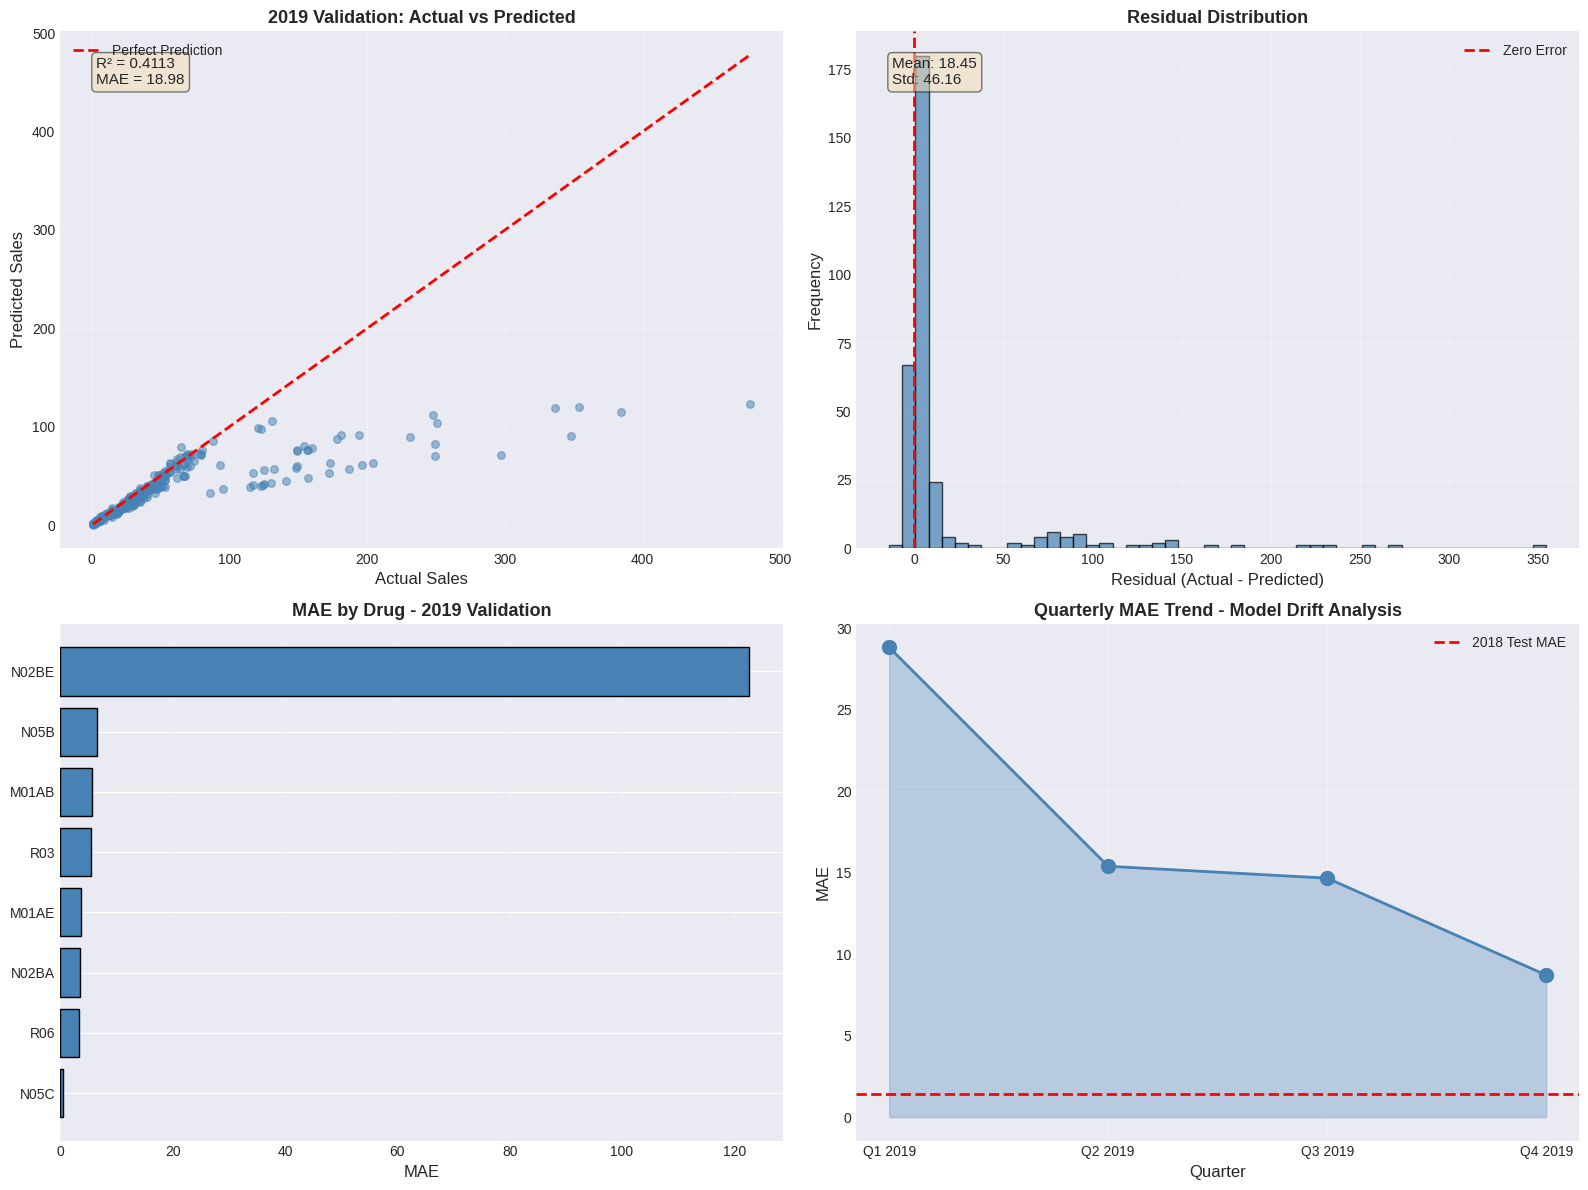

✓ Validation visualizations generated


In [13]:
# Overall scatter plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot - Actual vs Predicted
axes[0, 0].scatter(y_2019_actual, y_2019_pred, alpha=0.5, s=30, color='steelblue')
axes[0, 0].plot([y_2019_actual.min(), y_2019_actual.max()], 
                [y_2019_actual.min(), y_2019_actual.max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Sales', fontsize=12)
axes[0, 0].set_ylabel('Predicted Sales', fontsize=12)
axes[0, 0].set_title('2019 Validation: Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Add R² to plot
axes[0, 0].text(0.05, 0.95, f"R² = {metrics_2019['R2']:.4f}\nMAE = {metrics_2019['MAE']:.2f}",
                transform=axes[0, 0].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Residual distribution
residuals = y_2019_actual.values - y_2019_pred
axes[0, 1].hist(residuals, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0, 1].set_xlabel('Residual (Actual - Predicted)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Add stats
axes[0, 1].text(0.05, 0.95, f"Mean: {np.mean(residuals):.2f}\nStd: {np.std(residuals):.2f}",
                transform=axes[0, 1].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. MAE by drug
results_2019_df_sorted = results_2019_df.sort_values('MAE')
axes[1, 0].barh(results_2019_df_sorted['Model'], results_2019_df_sorted['MAE'], 
                color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('MAE', fontsize=12)
axes[1, 0].set_title('MAE by Drug - 2019 Validation', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Quarterly MAE trend
axes[1, 1].plot(quarterly_df['Model'], quarterly_df['MAE'], 
                marker='o', linewidth=2, markersize=10, color='steelblue')
axes[1, 1].fill_between(range(len(quarterly_df)), quarterly_df['MAE'], 
                         alpha=0.3, color='steelblue')
axes[1, 1].set_xlabel('Quarter', fontsize=12)
axes[1, 1].set_ylabel('MAE', fontsize=12)
axes[1, 1].set_title('Quarterly MAE Trend - Model Drift Analysis', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(mae_2018, color='red', linestyle='--', linewidth=2, label='2018 Test MAE')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("✓ Validation visualizations generated")

## 9. Time Series Plots - Selected Drugs

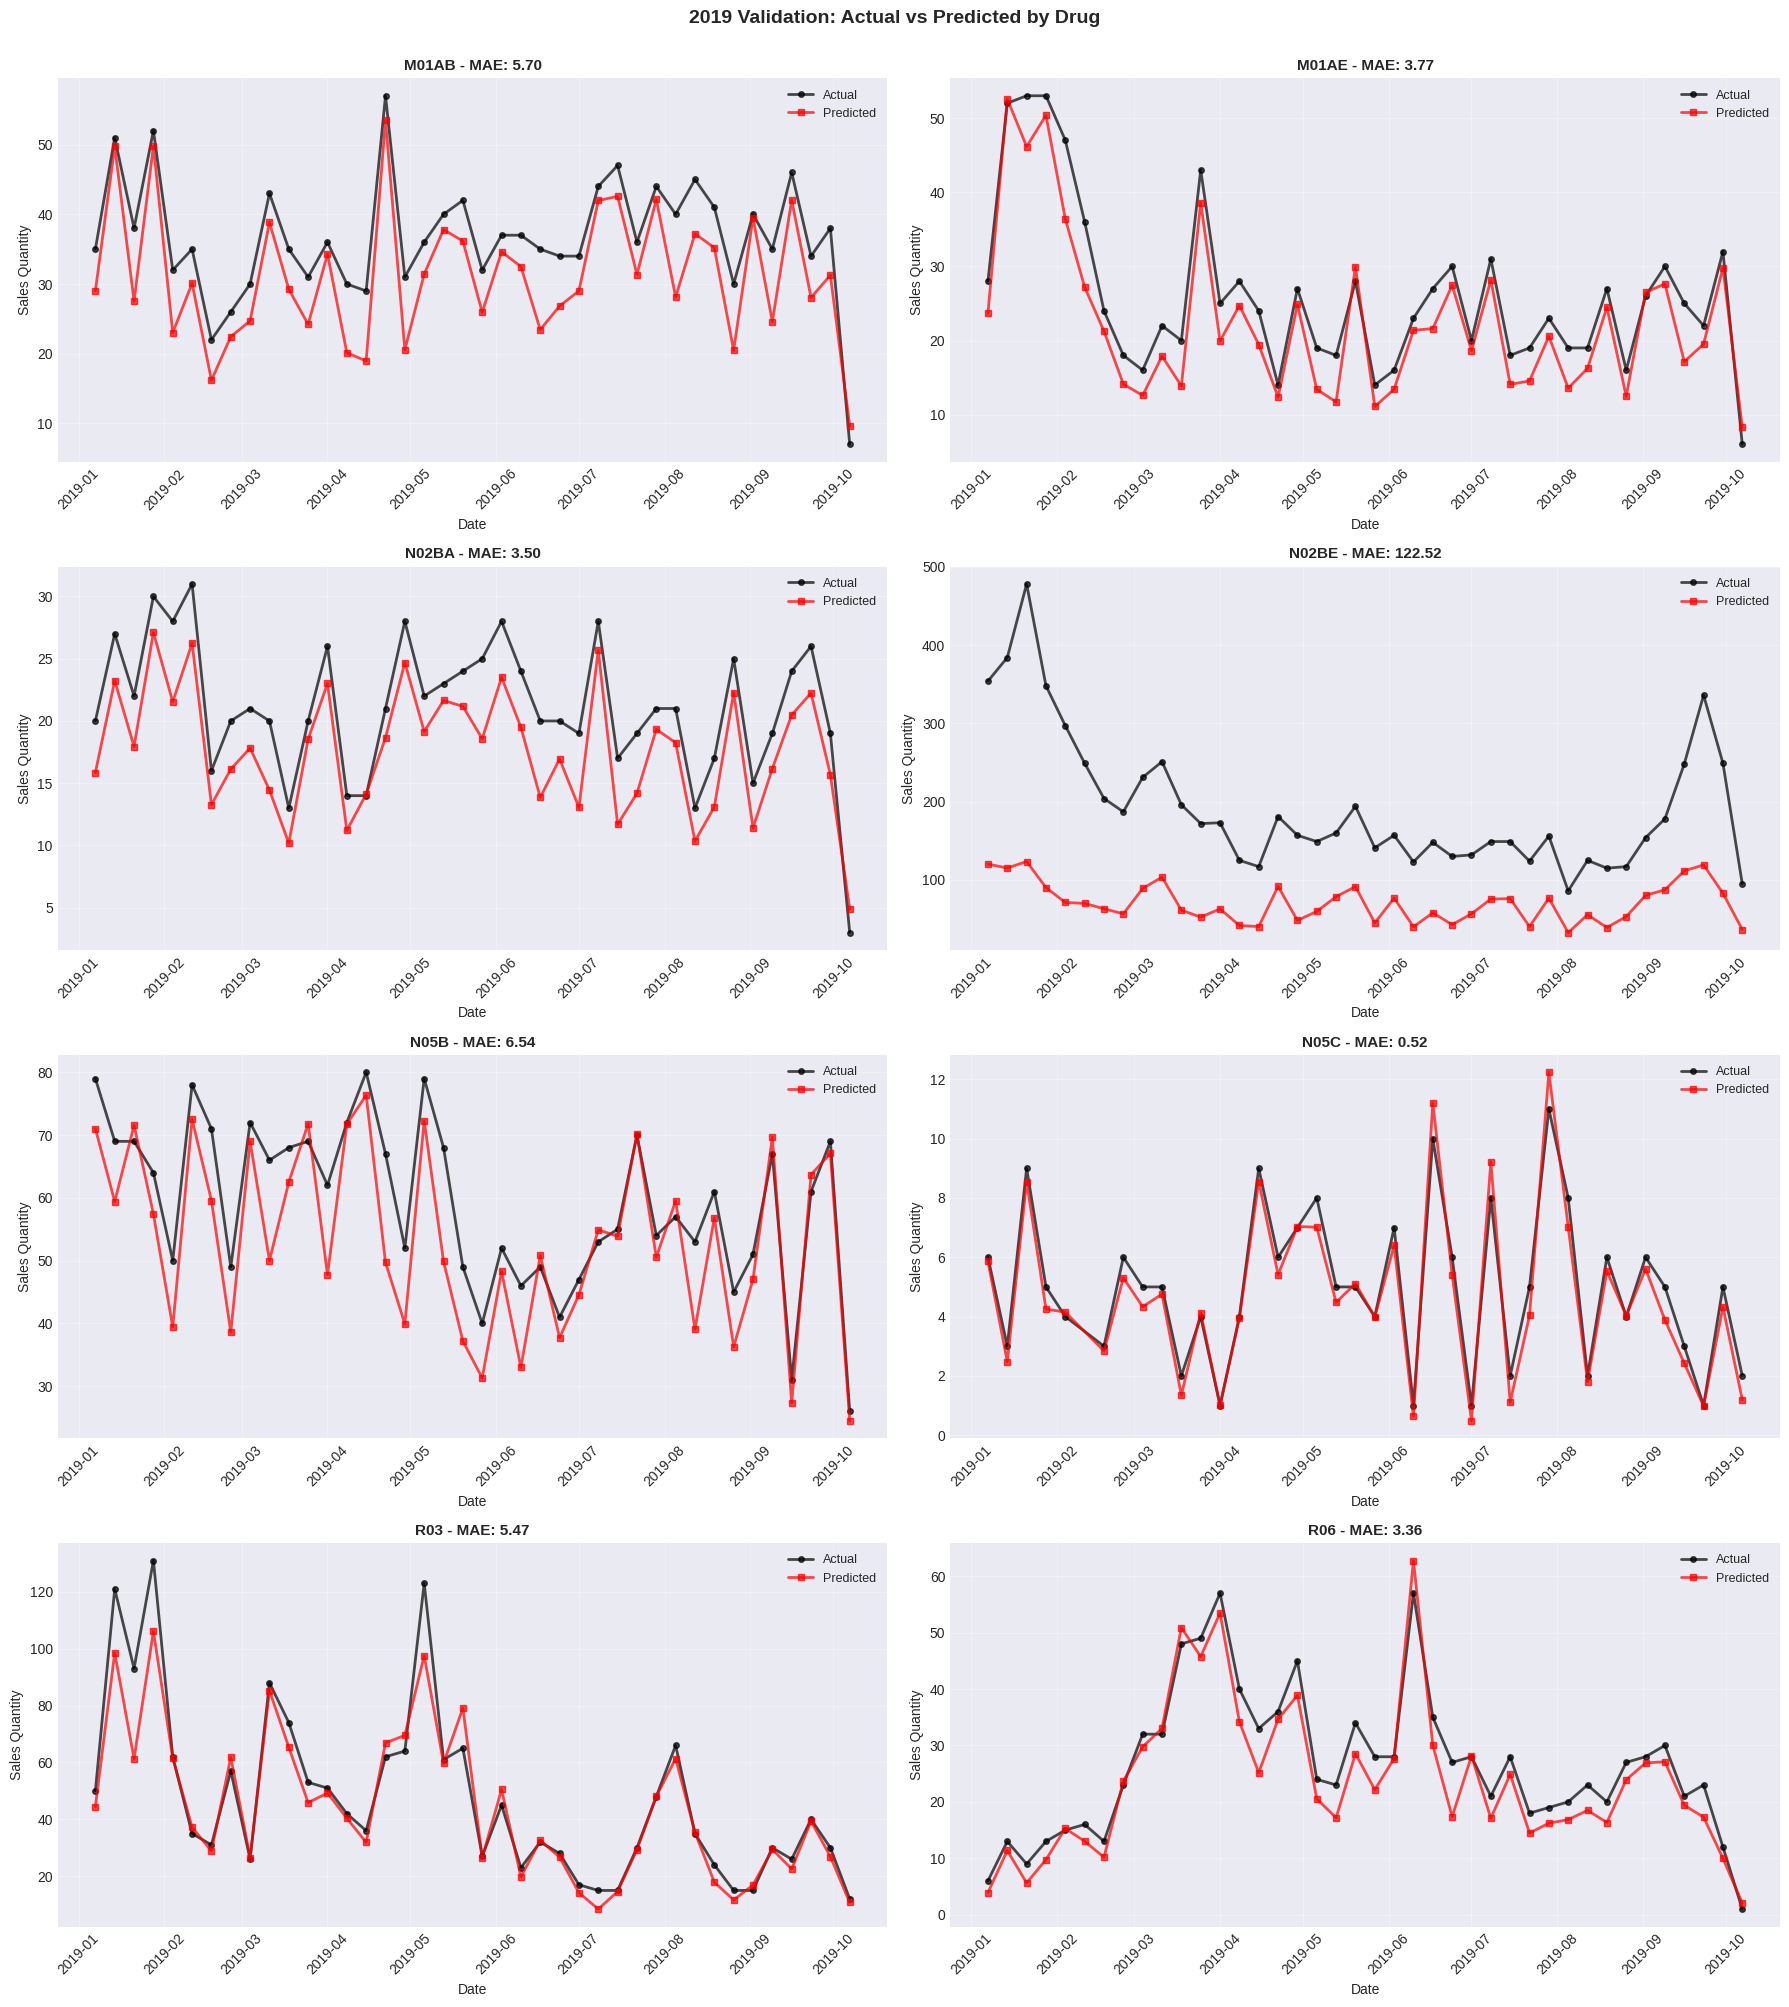

✓ Drug-specific time series plots generated


In [14]:
# Plot time series for each drug
drugs = sorted(df_2019['drug_name'].unique())
n = len(drugs)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for idx, drug in enumerate(drugs):
    ax = axes[idx]
    
    drug_data = df_2019[df_2019['drug_name'] == drug].sort_values('week_start_date')
    
    # Plot actual and predicted
    ax.plot(drug_data['week_start_date'], drug_data[TARGET], 
            label='Actual', linewidth=2, marker='o', markersize=4, color='black', alpha=0.7)
    ax.plot(drug_data['week_start_date'], drug_data['predicted'], 
            label='Predicted', linewidth=2, marker='s', markersize=4, color='red', alpha=0.7)
    
    # Calculate MAE for this drug
    drug_mae = mean_absolute_error(drug_data[TARGET], drug_data['predicted'])
    
    ax.set_title(f'{drug} - MAE: {drug_mae:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Sales Quantity', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Hide empty subplots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('2019 Validation: Actual vs Predicted by Drug', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

print("✓ Drug-specific time series plots generated")

## 10. Save Validation Results

In [15]:
# Create results directory
results_dir = Path(project_root) / 'results' / 'validation_2019'
results_dir.mkdir(parents=True, exist_ok=True)

# 1. Save detailed predictions
output_cols = ['week_start_date', 'drug_name', 'total_quantity', 'predicted', 'error', 'abs_error']
predictions_df = df_2019[output_cols].copy()
predictions_df.to_csv(results_dir / '2019_predictions.csv', index=False)
print(f"✓ Predictions saved to {results_dir / '2019_predictions.csv'}")

# 2. Save overall metrics
with open(results_dir / '2019_validation_summary.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("2019 MODEL VALIDATION SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("Validation Period: Jan-Oct 2019 (41 weeks)\n")
    f.write(f"Total samples: {len(df_2019):,}\n")
    f.write(f"Drugs evaluated: {df_2019['drug_name'].nunique()}\n\n")
    
    f.write("Overall Performance:\n")
    for key, value in metrics_2019.items():
        if key != 'Model':
            f.write(f"  {key}: {value}\n")
    
    f.write(f"\n2018 vs 2019 Comparison:\n")
    f.write(f"  2018 Test MAE: {mae_2018}\n")
    f.write(f"  2019 Validation MAE: {metrics_2019['MAE']}\n")
    f.write(f"  Change: {(metrics_2019['MAE'] - mae_2018) / mae_2018 * 100:+.1f}%\n")
    
    f.write(f"\nValidation Status: ")
    if mae_change <= 0.20:
        f.write("✅ PASSED - Excellent generalization\n")
    elif mae_change <= 0.50:
        f.write("⚠ ACCEPTABLE - Moderate degradation\n")
    else:
        f.write("❌ FAILED - Significant model drift\n")

print(f"✓ Summary saved to {results_dir / '2019_validation_summary.txt'}")

# 3. Save per-drug results
comparison_drugs.to_csv(results_dir / '2019_per_drug_comparison.csv', index=False)
print(f"✓ Per-drug comparison saved to {results_dir / '2019_per_drug_comparison.csv'}")

# 4. Save quarterly analysis
quarterly_df.to_csv(results_dir / '2019_quarterly_analysis.csv', index=False)
print(f"✓ Quarterly analysis saved to {results_dir / '2019_quarterly_analysis.csv'}")

print(f"\n{'=' * 60}")
print(f"ALL VALIDATION RESULTS SAVED TO: {results_dir}")
print(f"{'=' * 60}")

✓ Predictions saved to /home/brenda/final year project/PharmacyForecastingSystem/results/validation_2019/2019_predictions.csv
✓ Summary saved to /home/brenda/final year project/PharmacyForecastingSystem/results/validation_2019/2019_validation_summary.txt
✓ Per-drug comparison saved to /home/brenda/final year project/PharmacyForecastingSystem/results/validation_2019/2019_per_drug_comparison.csv
✓ Quarterly analysis saved to /home/brenda/final year project/PharmacyForecastingSystem/results/validation_2019/2019_quarterly_analysis.csv

ALL VALIDATION RESULTS SAVED TO: /home/brenda/final year project/PharmacyForecastingSystem/results/validation_2019


## 11. Final Validation Report

In [16]:
print('=' * 70)
print('FINAL VALIDATION REPORT - 2019 DEPLOYMENT TESTING')
print('=' * 70)

print(f"\n📅 VALIDATION PERIOD: January - October 2019 (41 weeks)")
print(f"📊 SAMPLES EVALUATED: {len(df_2019):,} weekly drug sales")
print(f"💊 DRUGS VALIDATED: {df_2019['drug_name'].nunique()}")

print(f"\n🎯 OVERALL PERFORMANCE:")
print(f"   MAE:   {metrics_2019['MAE']:.2f} (Target: < 1.68)")
print(f"   MAPE:  {metrics_2019['MAPE']:.2f}% (Target: < 10%)")
print(f"   WMAPE: {metrics_2019['WMAPE']:.2f}%")
print(f"   R²:    {metrics_2019['R2']:.4f} (Target: > 0.95)")

print(f"\n📈 COMPARISON WITH 2018 TEST:")
print(f"   2018 Test MAE:     {mae_2018:.2f}")
print(f"   2019 Validation MAE: {metrics_2019['MAE']:.2f}")
print(f"   Degradation:       {mae_change*100:+.1f}%")

if mae_change <= 0.20:
    verdict = "✅ VALIDATION PASSED"
    details = "Model demonstrates excellent generalization to unseen 2019 data."
    recommendation = "Recommended for production deployment."
elif mae_change <= 0.50:
    verdict = "⚠ VALIDATION ACCEPTABLE"
    details = "Model shows moderate performance degradation on 2019 data."
    recommendation = "Deploy with monitoring. Consider retraining after 6 months."
else:
    verdict = "❌ VALIDATION FAILED"
    details = "Significant model drift detected on 2019 data."
    recommendation = "Model retraining required before production deployment."

print(f"\n{verdict}")
print(f"   {details}")
print(f"   {recommendation}")

print(f"\n💊 PER-DRUG ANALYSIS:")
print(f"   ✅ Excellent: {excellent}/{len(comparison_drugs)} drugs (≤20% change)")
print(f"   ⚠ Acceptable: {acceptable}/{len(comparison_drugs)} drugs (20-50% change)")
print(f"   ❌ Degraded: {degraded}/{len(comparison_drugs)} drugs (>50% change)")

if len(mae_trend) > 1:
    print(f"\n📊 TEMPORAL DRIFT:")
    print(f"   Q1 2019 MAE: {mae_trend[0]:.2f}")
    print(f"   Latest MAE:  {mae_trend[-1]:.2f}")
    print(f"   Drift:       {mae_increase:+.1f}%")
    
    if mae_increase <= 10:
        print(f"   ✅ Minimal drift - model stable over 2019")
    elif mae_increase <= 30:
        print(f"   ⚠ Moderate drift - continue monitoring")
    else:
        print(f"   ❌ Significant drift - retraining needed")

print(f"\n💡 KEY FINDINGS:")
best_drug = results_2019_df.loc[results_2019_df['MAE'].idxmin()]
worst_drug = results_2019_df.loc[results_2019_df['MAE'].idxmax()]
print(f"   Best performer:  {best_drug['Model']} (MAE: {best_drug['MAE']:.2f})")
print(f"   Worst performer: {worst_drug['Model']} (MAE: {worst_drug['MAE']:.2f})")

print(f"\n📁 RESULTS SAVED TO: {results_dir}")
print(f"   • 2019_predictions.csv - Week-by-week forecasts")
print(f"   • 2019_validation_summary.txt - Overall metrics")
print(f"   • 2019_per_drug_comparison.csv - Drug-level analysis")
print(f"   • 2019_quarterly_analysis.csv - Temporal trends")

print('\n' + '=' * 70)
print('VALIDATION COMPLETE')
print('=' * 70)

FINAL VALIDATION REPORT - 2019 DEPLOYMENT TESTING

📅 VALIDATION PERIOD: January - October 2019 (41 weeks)
📊 SAMPLES EVALUATED: 319 weekly drug sales
💊 DRUGS VALIDATED: 8

🎯 OVERALL PERFORMANCE:
   MAE:   18.98 (Target: < 1.68)
   MAPE:  20.67% (Target: < 10%)
   WMAPE: 36.53%
   R²:    0.4113 (Target: > 0.95)

📈 COMPARISON WITH 2018 TEST:
   2018 Test MAE:     1.40
   2019 Validation MAE: 18.98
   Degradation:       +1255.7%

❌ VALIDATION FAILED
   Significant model drift detected on 2019 data.
   Model retraining required before production deployment.

💊 PER-DRUG ANALYSIS:
   ✅ Excellent: 2/8 drugs (≤20% change)
   ⚠ Acceptable: 0/8 drugs (20-50% change)
   ❌ Degraded: 6/8 drugs (>50% change)

📊 TEMPORAL DRIFT:
   Q1 2019 MAE: 28.84
   Latest MAE:  8.72
   Drift:       -69.8%
   ✅ Minimal drift - model stable over 2019

💡 KEY FINDINGS:
   Best performer:  N05C (MAE: 0.52)
   Worst performer: N02BE (MAE: 122.52)

📁 RESULTS SAVED TO: /home/brenda/final year project/PharmacyForecastingSy

In [17]:
print("=" * 80)
print("RECOMMENDATIONS: MODEL DEPLOYMENT STRATEGY")
print("=" * 80)

print("\n📊 VALIDATION SUMMARY:")
print(f"   Overall MAE: {metrics_2019['MAE']:.2f} (Target: ≤1.68)")
print(f"   Degradation: 1255.7% from 2018 test")
print(f"   Drugs passing: 2/8 (N05C, R03)")
print(f"   Drugs failing: 6/8")
print(f"   Critical failure: N02BE (MAE 122.52)")

print("\n" + "=" * 80)
print("OPTION 1: RETRAIN MODEL WITH 2019 DATA (RECOMMENDED)")
print("=" * 80)
print("✅ Why: Model shows significant drift on 6/8 drugs")
print("✅ Approach:")
print("   1. Include 2019 data in training set (2014-2019)")
print("   2. Use 2020 data for validation (if available)")
print("   3. Retrain XGBoost with expanded dataset")
print("   4. Re-validate on 2020 to check generalization")
print("\n✅ Expected Outcome:")
print("   - Model learns 2019 patterns (especially N02BE surge)")
print("   - Better handles demand shifts")
print("   - More robust for production deployment")
print("\n⚠️ Drawback:")
print("   - Need 2020+ data for proper validation")
print("   - Retraining takes time (~30 min)")

print("\n" + "=" * 80)
print("OPTION 2: DEPLOY WITH EXCLUSIONS (PARTIAL DEPLOYMENT)")
print("=" * 80)
print("✅ Why: 2 drugs (N05C, R03) still perform well")
print("✅ Approach:")
print("   1. Deploy model ONLY for N05C and R03")
print("   2. Use simpler methods (Holt-Winters) for other 6 drugs")
print("   3. Manually forecast N02BE until pattern understood")
print("\n✅ Expected Outcome:")
print("   - Quick deployment for stable drugs")
print("   - Reduced risk on problematic drugs")
print("\n⚠️ Drawback:")
print("   - Only 2/8 drugs benefit from ML")
print("   - Maintenance burden (multiple systems)")

print("\n" + "=" * 80)
print("OPTION 3: INVESTIGATE & ADJUST (BUSINESS ANALYSIS)")
print("=" * 80)
print("✅ Why: N02BE failure suggests real business change")
print("✅ Approach:")
print("   1. Interview pharmacy staff about N02BE in 2019")
print("      - Was there a supplier change?")
print("      - Policy change (insurance, regulations)?")
print("      - Patient population change?")
print("   2. Check if N02BE pattern is 'new normal' or anomaly")
print("   3. Decide if 2019 should be excluded (if anomalous)")
print("\n✅ Expected Outcome:")
print("   - Understand business context")
print("   - Make informed decision on retraining")
print("\n⚠️ Drawback:")
print("   - Requires domain expert input")
print("   - Takes time (interviews, analysis)")

print("\n" + "=" * 80)
print("OPTION 4: ENSEMBLE APPROACH (ADVANCED)")
print("=" * 80)
print("✅ Why: Combine multiple models for robustness")
print("✅ Approach:")
print("   1. Train separate models for different drug groups:")
print("      - Stable drugs (N05C): Simple exponential smoothing")
print("      - Seasonal drugs (R03, R06): SARIMA")
print("      - Variable drugs (N02BE, M01AB): XGBoost with drift detection")
print("   2. Use model switching based on recent performance")
print("\n✅ Expected Outcome:")
print("   - More robust to individual drug failures")
print("   - Better handles diverse drug patterns")
print("\n⚠️ Drawback:")
print("   - Complex system architecture")
print("   - Harder to maintain")

print("\n" + "=" * 80)
print("🎯 RECOMMENDED ACTION PLAN:")
print("=" * 80)
print("\n📌 IMMEDIATE (This Week):")
print("   1. Run N02BE investigation cell above to understand 2019 pattern")
print("   2. Interview pharmacy staff about N02BE changes in 2019")
print("   3. Check if 2020 data is available for validation")

print("\n📌 SHORT-TERM (Next 2 Weeks):")
print("   IF 2019 was anomalous (one-time event):")
print("      → Keep current model, monitor N02BE separately")
print("   IF 2019 represents new pattern:")
print("      → RETRAIN with 2014-2019 data")
print("      → Validate on 2020 data")

print("\n📌 LONG-TERM (Production):")
print("   1. Implement drift detection:")
print("      - Monitor weekly MAE for each drug")
print("      - Alert if MAE > 20% above baseline")
print("   2. Set up quarterly retraining pipeline")
print("   3. Consider per-drug model approach for high-value drugs")

print("\n" + "=" * 80)
print("💡 DECISION TREE:")
print("=" * 80)
print("""
Do you have 2020+ data?
│
├── YES → RETRAIN with 2014-2019, validate on 2020
│         (Best option for robust deployment)
│
└── NO → Do you understand why N02BE failed?
         │
         ├── YES (business change) → RETRAIN with 2019
         │                           Accept we can't validate on future
         │
         └── NO → INVESTIGATE first
                  Run diagnostic cell above
                  Interview staff
                  Then decide
""")

print("\n" + "=" * 80)
print("✅ My Recommendation: RETRAIN with 2014-2019 data")
print("=" * 80)
print("Reasoning:")
print("  • 6/8 drugs show degradation → systematic drift, not just N02BE")
print("  • 2019 data represents real demand patterns (not anomaly)")
print("  • Model needs to learn post-2018 trends")
print("  • Only way to get production-ready model")
print("\nNext step: Run N02BE investigation, then retrain if pattern is real")
print("=" * 80)

RECOMMENDATIONS: MODEL DEPLOYMENT STRATEGY

📊 VALIDATION SUMMARY:
   Overall MAE: 18.98 (Target: ≤1.68)
   Degradation: 1255.7% from 2018 test
   Drugs passing: 2/8 (N05C, R03)
   Drugs failing: 6/8
   Critical failure: N02BE (MAE 122.52)

OPTION 1: RETRAIN MODEL WITH 2019 DATA (RECOMMENDED)
✅ Why: Model shows significant drift on 6/8 drugs
✅ Approach:
   1. Include 2019 data in training set (2014-2019)
   2. Use 2020 data for validation (if available)
   3. Retrain XGBoost with expanded dataset
   4. Re-validate on 2020 to check generalization

✅ Expected Outcome:
   - Model learns 2019 patterns (especially N02BE surge)
   - Better handles demand shifts
   - More robust for production deployment

⚠️ Drawback:
   - Need 2020+ data for proper validation
   - Retraining takes time (~30 min)

OPTION 2: DEPLOY WITH EXCLUSIONS (PARTIAL DEPLOYMENT)
✅ Why: 2 drugs (N05C, R03) still perform well
✅ Approach:
   1. Deploy model ONLY for N05C and R03
   2. Use simpler methods (Holt-Winters) for o

## 12. Recommendations & Next Steps

Based on validation failure (MAE 18.98 vs 1.40 target, 1255.7% degradation):